Number of loans with resolved status: 1345350
Number of loans with unresolved status: 915318
Percentage of loans with unresolved status: 40.49%
Number of fully paid loans: 1076751
Number of defaulted loans: 268599
Base rate of default: 19.96%


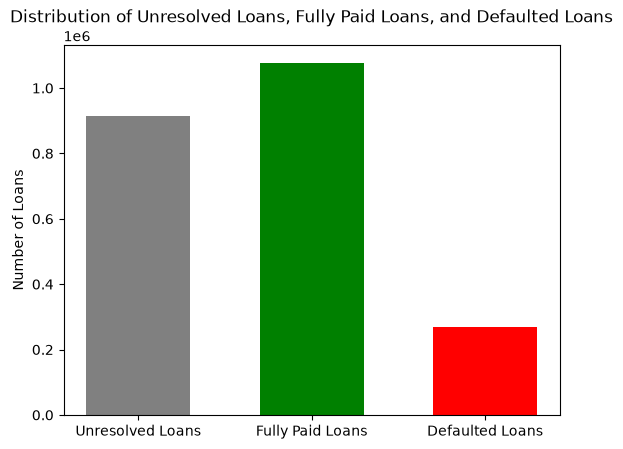

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

path = "data/interim/accepted_2007_to_2018Q4.parquet"

df = pd.read_parquet(path)


resolved = df[df["loan_status"].isin(["Fully Paid", "Charged Off", "Default"])]
fully_paid = (resolved["loan_status"] == "Fully Paid").sum()
defaulted = resolved["loan_status"].isin(["Charged Off", "Default"]).sum()

print(f"Number of loans with resolved status: {len(resolved)}")
print(f"Number of loans with unresolved status: {len(df) - len(resolved)}")
print(
    f"Percentage of loans with unresolved status: {(len(df) - len(resolved)) / len(df):.2%}"
)
print(f"Number of fully paid loans: {fully_paid}")
print(f"Number of defaulted loans: {defaulted}")

base_rate = (resolved["loan_status"].isin(["Charged Off", "Default"])).mean()

print(f"Base rate of default: {base_rate:.2%}")

plt.bar(
    ["Unresolved Loans", "Fully Paid Loans", "Defaulted Loans"],
    [len(df) - len(resolved), fully_paid, defaulted],
    width=0.6,
    color=["grey", "green", "red"],
)
plt.ylabel("Number of Loans")
plt.title("Distribution of Unresolved Loans, Fully Paid Loans, and Defaulted Loans")
plt.show()


<Axes: title={'center': 'Missing Values by Column'}>

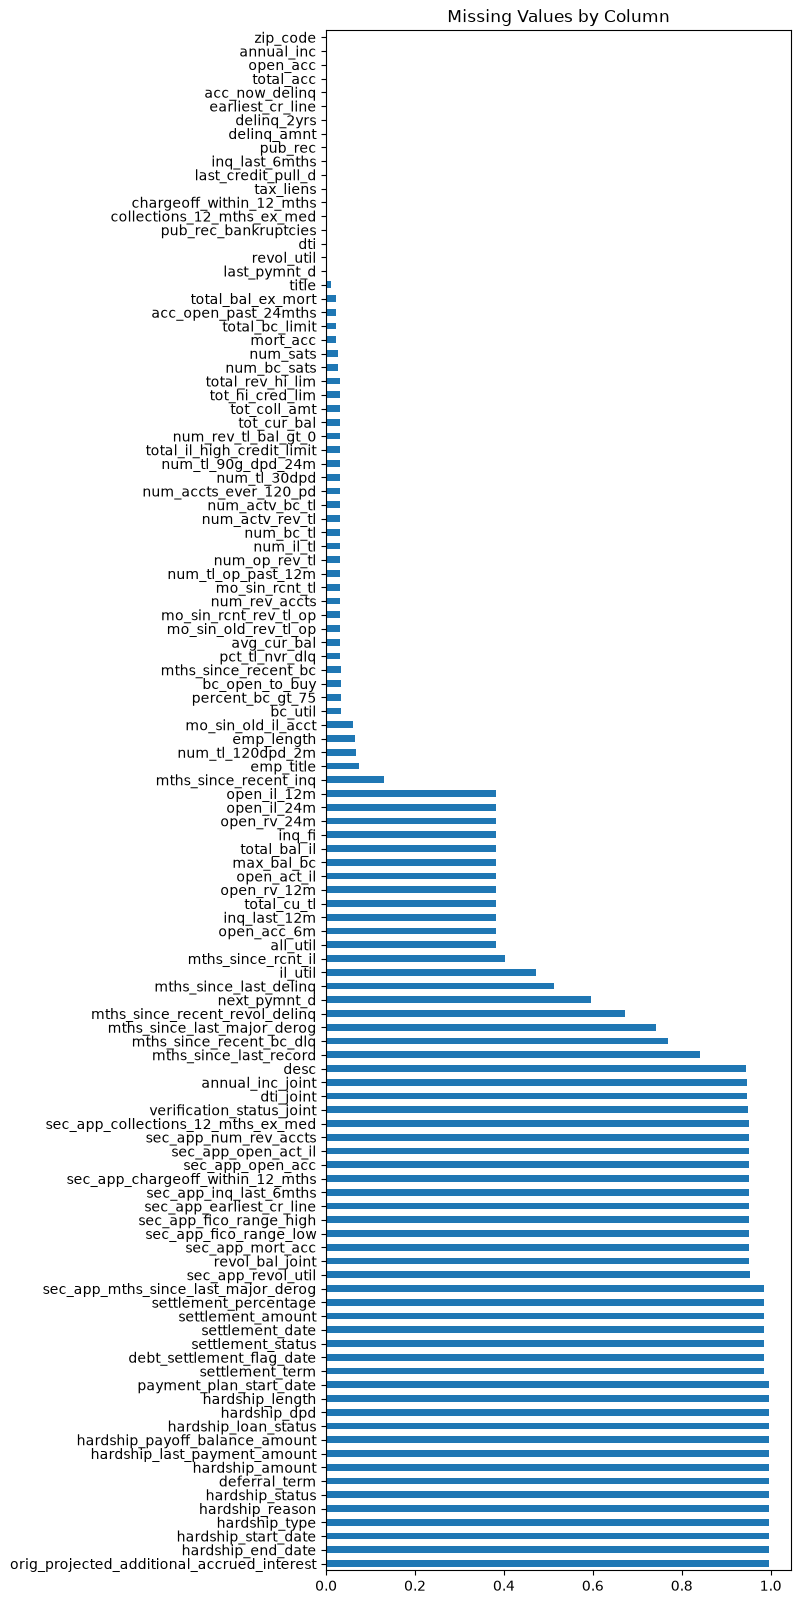

In [2]:
df = df.drop(columns=["member_id"])  # 100% null, dead column

missing_pct = df.isnull().mean().sort_values(ascending=False)
missing_pct[missing_pct > 0].plot(
    kind="barh", figsize=(6, 20), title="Missing Values by Column"
)

# Understanding Week 1

## Filtering

Filtered `loan_status` to "Fully Paid" (1,076,751) vs "Charged Off" + "Default" (268,599). Dropped in-progress statuses ("Current", "Late", "In Grace Period") since they have no final outcome yet. "Does not meet the credit policy" statuses are excluded automatically by the exact-string `.isin()` match.

## Base rate

The base rate is 19.96%. No surprises. This confirms the class imbalance that will need to be handled (class weighting / stratified splits) rather than plain accuracy later.

## Missingness

`member_id` is entirely null (dead column), safe to drop outright. The next tier of missing columns (~98–99.5% null) are all hardship/settlement fields (`hardship_*`, `settlement_*`). These are missing because those events are rare, not because of a data quality problem. These overlap with the post-origination leakage columns flagged for removal in Week 2, so their missingness is a non-issue for modeling either way.
